<a href="https://colab.research.google.com/github/rashmib21/Data-Analysis-of-Stock-Market-from-2016-to-2026/blob/main/ARIMAX_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [10]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.3 MB/s eta 0:00:00


In [18]:
!pip install pmdarima
!pip install odfpy

import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import seaborn as sns

# Load the ODS file
df = pd.read_excel('Hindustan_copper.ods', engine='odf')

# Parse datetime column, set as index, and sort
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime').sort_index()

# Assign business day frequency and forward fill missing dates if any
df = df.asfreq('B', method='ffill')

# Display first few rows and info
print("DataFrame head:")
display(df.head())
print("\nDataFrame info:")
df.info()

DataFrame head:


,symbol,open,high,low,close,volume
datetime,,,,,,
2016-01-04 00:00:00+05:30,HINDALCO,84.20,85.90,80.4,80.75,8706224
2016-01-05 00:00:00+05:30,HINDALCO,82.00,83.95,80.6,82.60,9819068
2016-01-06 00:00:00+05:30,HINDALCO,82.40,82.85,79.7,80.55,6494446
2016-01-07 00:00:00+05:30,HINDALCO,79.00,79.40,76.1,76.65,8098318
2016-01-08 00:00:00+05:30,HINDALCO,77.45,78.15,75.2,76.90,6800939



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2671 entries, 2016-01-04 00:00:00+05:30 to 2026-03-30 00:00:00+05:30
Freq: B
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   symbol  2671 non-null   object 
 1   open    2671 non-null   float64
 2   high    2671 non-null   float64
 3   low     2671 non-null   float64
 4   close   2671 non-null   float64
 5   volume  2671 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 146.1+ KB


### Define Endogenous (Target) and Exogenous (Input) Variables

In [19]:
endog = df['close']
exog = df[['open', 'high', 'low', 'volume']]

print("Endogenous variable (Close price) head:")
display(endog.head())
print("\nExogenous variables (Open, High, Low, Volume) head:")
display(exog.head())

Endogenous variable (Close price) head:


,close
datetime,
2016-01-04 00:00:00+05:30,80.75
2016-01-05 00:00:00+05:30,82.60
2016-01-06 00:00:00+05:30,80.55
2016-01-07 00:00:00+05:30,76.65
2016-01-08 00:00:00+05:30,76.90



Exogenous variables (Open, High, Low, Volume) head:


,open,high,low,volume
datetime,,,,
2016-01-04 00:00:00+05:30,84.20,85.90,80.4,8706224
2016-01-05 00:00:00+05:30,82.00,83.95,80.6,9819068
2016-01-06 00:00:00+05:30,82.40,82.85,79.7,6494446
2016-01-07 00:00:00+05:30,79.00,79.40,76.1,8098318
2016-01-08 00:00:00+05:30,77.45,78.15,75.2,6800939


### Split Data into Training and Testing Sets (80% train, 20% test)

In [20]:
# This cell depends on 'endog' and 'exog' being defined in previous cells.
train_size = int(len(endog) * 0.8)
endog_train, endog_test = endog[:train_size], endog[train_size:]
exog_train, exog_test = exog[:train_size], exog[train_size:]

print(f"Training data size: {len(endog_train)}")
print(f"Testing data size: {len(endog_test)}")

Training data size: 2136
Testing data size: 535


### Find Best ARIMAX Order (p,d,q) using `auto_arima`

In [21]:
model_auto = auto_arima(endog_train, exogenous=exog_train,
                        seasonal=False, stepwise=True,
                        suppress_warnings=True, error_action='ignore')
best_order = model_auto.order
print(f"Best ARIMAX Order (p,d,q): {best_order}")

Best ARIMAX Order (p,d,q): (3, 1, 2)


### Walk-Forward Validation

In [22]:
history_endog = [x for x in endog_train]
history_exog = exog_train.values.tolist()
predictions = []

print("Performing walk-forward validation...")
for t in range(len(endog_test)):
    if t % 50 == 0:
        print(f"  Forecasting step {t+1}/{len(endog_test)}")

    # Fit ARIMAX model with best order
    model = ARIMA(history_endog, exog=history_exog, order=best_order)
    model_fit = model.fit(method='innovations_mle', low_memory=True)

    # Make one-step forecast with current test exog row
    yhat = model_fit.forecast(steps=1, exog=exog_test.iloc[[t]])[0]
    predictions.append(yhat)

    # Append actual observation to history for next iteration
    history_endog.append(endog_test.iloc[t])
    history_exog.append(exog_test.iloc[t].tolist())

# Convert predictions to a pandas Series with the test set index
predictions_series = pd.Series(predictions, index=endog_test.index)

print("Walk-forward validation complete.")

Performing walk-forward validation...
  Forecasting step 1/535
  Forecasting step 51/535
  Forecasting step 101/535
  Forecasting step 151/535
  Forecasting step 201/535
  Forecasting step 251/535
  Forecasting step 301/535
  Forecasting step 351/535
  Forecasting step 401/535
  Forecasting step 451/535
  Forecasting step 501/535
Walk-forward validation complete.


### Evaluate Model Performance (RMSE)

In [23]:
rmse = np.sqrt(mean_squared_error(endog_test, predictions_series))
print(f"RMSE: {rmse:.3f}")

RMSE: 5.211


### Visualize Predicted vs Actual Close Price

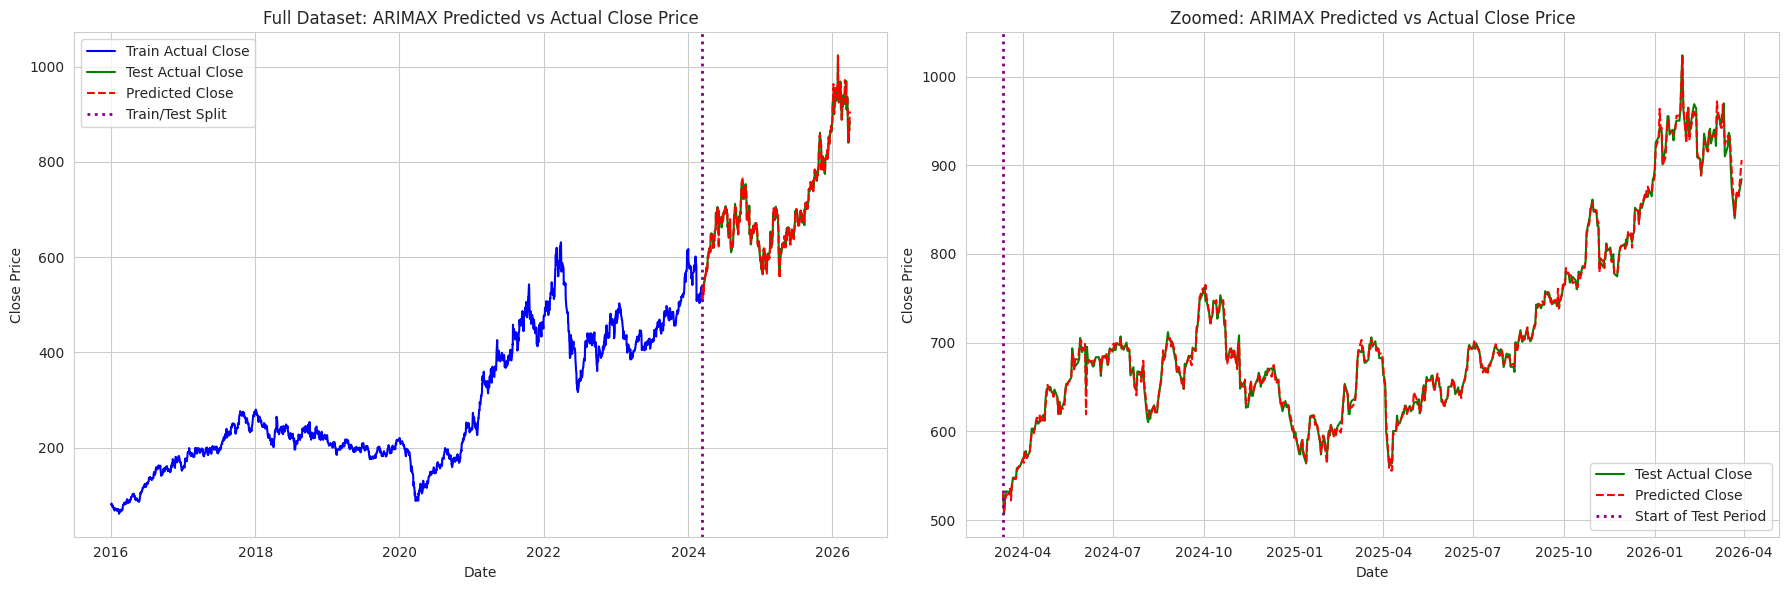

In [24]:
plt.figure(figsize=(18, 6))
sns.set_style("whitegrid")

# Subplot 1: Full Dataset View
plt.subplot(1, 2, 1)
plt.plot(endog_train.index, endog_train, label='Train Actual Close', color='blue')
plt.plot(endog_test.index, endog_test, label='Test Actual Close', color='green')
plt.plot(predictions_series.index, predictions_series, label='Predicted Close', color='red', linestyle='--')
plt.axvline(x=endog_train.index[-1], color='purple', linestyle=':', linewidth=2, label='Train/Test Split')
plt.title('Full Dataset: ARIMAX Predicted vs Actual Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)

# Subplot 2: Zoomed Test-Only View
plt.subplot(1, 2, 2)
plt.plot(endog_test.index, endog_test, label='Test Actual Close', color='green')
plt.plot(predictions_series.index, predictions_series, label='Predicted Close', color='red', linestyle='--')
plt.axvline(x=endog_test.index[0], color='purple', linestyle=':', linewidth=2, label='Start of Test Period')
plt.title('Zoomed: ARIMAX Predicted vs Actual Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Final Summary

In [25]:
print(f"Model        : ARIMAX")
print(f"ARIMA Order  : {best_order}")
print(f"Exog Variables: Open, High, Low, Volume")
print(f"Target        : Close")
print(f"RMSE          : {rmse:.3f}")

Model        : ARIMAX
ARIMA Order  : (3, 1, 2)
Exog Variables: Open, High, Low, Volume
Target        : Close
RMSE          : 5.211
